## Modelo de regresion con ingenieria de variables

En esta seccion se implementa un flujo completo para predecir Consumption:
- Carga y exploracion del CSV original.
- Analisis de variables candidatas desde el dataset fuente.
- Ingenieria temporal + one-hot encoding para hour, day_of_week, month, quarter y year.
- Split tradicional aleatorio train/validation/test (no temporal).
- Entrenamiento y evaluacion con LinearRegression.
- Visualizacion de predicciones y residuales.

In [53]:
# Librerias base para manipulacion de datos y visualizacion
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modelo lineal y metricas de evaluacion
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Herramientas de preprocesamiento y split tradicional
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Ajustes de visualizacion para tablas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

In [47]:
# Construimos una ruta relativa robusta al archivo fuente
csv_path = Path('code') / 'electricityConsumptionAndProductioction.csv'
if not csv_path.exists():
    raise FileNotFoundError(f'No se encontro el archivo: {csv_path.resolve()}')

# Cargamos datos originales (consumo + produccion por fuente)
raw = pd.read_csv(csv_path)

# Convertimos DateTime a formato fecha y lo usamos como indice temporal
raw['DateTime'] = pd.to_datetime(raw['DateTime'])
raw = raw.sort_values('DateTime').set_index('DateTime')

# Resumen rapido para entender tamano, columnas y posibles faltantes
print('Shape del dataset original:', raw.shape)
print('Columnas disponibles:', list(raw.columns))
print('Valores nulos por columna:')
print(raw.isna().sum())

# Visualizamos primeras filas del dataset completo
display(raw.head())

Shape del dataset original: (62810, 9)
Columnas disponibles: ['Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
Valores nulos por columna:
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [48]:
# Analisis de variables candidatas para explicar Consumption
# Evaluamos correlacion lineal de cada variable original contra el target.

candidate_cols = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'Consumption'
]

corr_with_target = raw[candidate_cols].corr(numeric_only=True)['Consumption'] \
    .drop('Consumption') \
    .sort_values(key=np.abs, ascending=False)

print('Correlacion (ordenada por magnitud absoluta) con Consumption:')
display(corr_with_target.to_frame('corr_vs_consumption'))

# Breve conclusion automatica de candidatas
strong_candidates = corr_with_target[np.abs(corr_with_target) >= 0.25].index.tolist()
moderate_candidates = corr_with_target[(np.abs(corr_with_target) >= 0.10) & (np.abs(corr_with_target) < 0.25)].index.tolist()

print('Candidatas fuertes (|corr| >= 0.25):', strong_candidates)
print('Candidatas moderadas (0.10 <= |corr| < 0.25):', moderate_candidates)

Correlacion (ordenada por magnitud absoluta) con Consumption:


,corr_vs_consumption
Production,0.690823
Oil and Gas,0.499442
Coal,0.472298
Biomass,0.400475
Hydroelectric,0.358047
Nuclear,0.161838
Wind,0.102026
Solar,-0.048037


Candidatas fuertes (|corr| >= 0.25): ['Production', 'Oil and Gas', 'Coal', 'Biomass', 'Hydroelectric']
Candidatas moderadas (0.10 <= |corr| < 0.25): ['Nuclear', 'Wind']


In [54]:
# Funcion para generar variables temporales a partir del indice de fechas
def create_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['hour'] = out.index.hour
    out['day_of_week'] = out.index.day_of_week
    out['month'] = out.index.month
    out['quarter'] = out.index.quarter
    out['year'] = out.index.year
    out['day_of_year'] = out.index.dayofyear
    return out

# Parte 1: ingenieria de variables (aislada, sin split)
feat_df = create_time_features(raw)

# Variables candidatas del dataset de origen (produccion total y por tecnologia)
energy_candidate_features = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass'
]

# Variables categoricas temporales a codificar con one-hot
categorical_time_features = ['hour', 'day_of_week', 'month', 'quarter', 'year']

# One-hot encoding para convertir categorias temporales en variables dummy
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
encoded_array = encoder.fit_transform(feat_df[categorical_time_features])
encoded_cols = encoder.get_feature_names_out(categorical_time_features)
encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=feat_df.index)

# Variables numericas adicionales (incluye dia del anio como tendencia estacional)
numeric_features = energy_candidate_features + ['day_of_year']

# Dataframe final de modelado con target + variables numericas + dummies temporales
model_df = pd.concat([
    feat_df[['Consumption'] + numeric_features],
    encoded_df
], axis=1)

TARGET = 'Consumption'
FEATURES = [col for col in model_df.columns if col != TARGET]

print('Ingenieria completada.')
print('Total de features para el modelo:', len(FEATURES))
print('Primeras 10 features:', FEATURES[:10])

Ingenieria completada.
Total de features para el modelo: 59
Primeras 10 features: ['Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'day_of_year', 'hour_1']


In [55]:
# Parte 2: split tradicional aleatorio train/validation/test + estandarizacion de variables energeticas
# Separamos primero train (70%) y temporalmente un bloque holdout (30%), luego dividimos holdout en val/test (15%/15%).
train_df, holdout_df = train_test_split(model_df, test_size=0.30, random_state=42, shuffle=True)
val_df, test_df = train_test_split(holdout_df, test_size=0.50, random_state=42, shuffle=True)

# Aseguramos tipo float en las variables a estandarizar para evitar errores de asignacion
cast_map = {col: 'float64' for col in energy_candidate_features}
train_df = train_df.astype(cast_map)
val_df = val_df.astype(cast_map)
test_df = test_df.astype(cast_map)

# Estandarizamos SOLO energy_candidate_features usando estadisticos de train
scaler = StandardScaler()
train_df.loc[:, energy_candidate_features] = scaler.fit_transform(train_df[energy_candidate_features])
val_df.loc[:, energy_candidate_features] = scaler.transform(val_df[energy_candidate_features])
test_df.loc[:, energy_candidate_features] = scaler.transform(test_df[energy_candidate_features])

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val, y_val = val_df[FEATURES], val_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print('Train size:', X_train.shape)
print('Validation size:', X_val.shape)
print('Test size:', X_test.shape)
print('Random state usado: 42')
print('Media train estandarizada (aprox 0):')
print(train_df[energy_candidate_features].mean().round(3).to_dict())
print('Std train estandarizada (aprox 1):')
print(train_df[energy_candidate_features].std().round(3).to_dict())

Train size: (43967, 59)
Validation size: (9421, 59)
Test size: (9422, 59)
Random state usado: 42
Media train estandarizada (aprox 0):
{'Production': 0.0, 'Nuclear': -0.0, 'Wind': -0.0, 'Hydroelectric': -0.0, 'Oil and Gas': -0.0, 'Coal': -0.0, 'Solar': 0.0, 'Biomass': -0.0}
Std train estandarizada (aprox 1):
{'Production': 1.0, 'Nuclear': 1.0, 'Wind': 1.0, 'Hydroelectric': 1.0, 'Oil and Gas': 1.0, 'Coal': 1.0, 'Solar': 1.0, 'Biomass': 1.0}


In [56]:
# Entrenamos un modelo de regresion lineal con todas las features ingenierizadas
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Generamos predicciones sobre validacion y prueba
pred_val = linear_model.predict(X_val)
pred_linear = linear_model.predict(X_test)

# Funcion auxiliar para error porcentual absoluto medio
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Resumen de metricas por split
results = pd.DataFrame([
    {
        'split': 'validation',
        'modelo': 'LinearRegression',
        'MAE': mean_absolute_error(y_val, pred_val),
        'RMSE': np.sqrt(mean_squared_error(y_val, pred_val)),
        'R2': r2_score(y_val, pred_val),
        'MAPE_%': mape(y_val, pred_val),
    },
    {
        'split': 'test',
        'modelo': 'LinearRegression',
        'MAE': mean_absolute_error(y_test, pred_linear),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_linear)),
        'R2': r2_score(y_test, pred_linear),
        'MAPE_%': mape(y_test, pred_linear),
    }
]).set_index(['split', 'modelo'])

# Analisis de importancia lineal por magnitud de coeficientes
coef_df = pd.DataFrame({
    'feature': FEATURES,
    'coef': linear_model.coef_,
    'abs_coef': np.abs(linear_model.coef_)
}).sort_values('abs_coef', ascending=False)

print('Top 12 features por magnitud de coeficiente:')
display(coef_df[['feature', 'coef']].head(12))

results.round(4)

Top 12 features por magnitud de coeficiente:


,feature,coef
21,hour_13,1379.481303
20,hour_12,1367.517107
19,hour_11,1366.308390
18,hour_10,1354.914952
22,hour_14,1270.879276
17,hour_9,1260.118401
28,hour_20,1203.606303
27,hour_19,1198.265964
26,hour_18,1190.716957
25,hour_17,1187.348805


,,MAE,RMSE,R2,MAPE_%
split,modelo,,,,
validation,LinearRegression,328.4579,428.3828,0.8373,5.2346
test,LinearRegression,320.9106,421.1752,0.8443,5.1271


Resumen de error en test:
       error_linear  abs_error
count      9422.000   9422.000
mean          0.290    320.911
std         421.197    272.787
min       -2359.497      0.024
25%        -252.551    120.389
50%          -0.683    256.267
75%         258.573    454.844
max        3650.059   3650.059


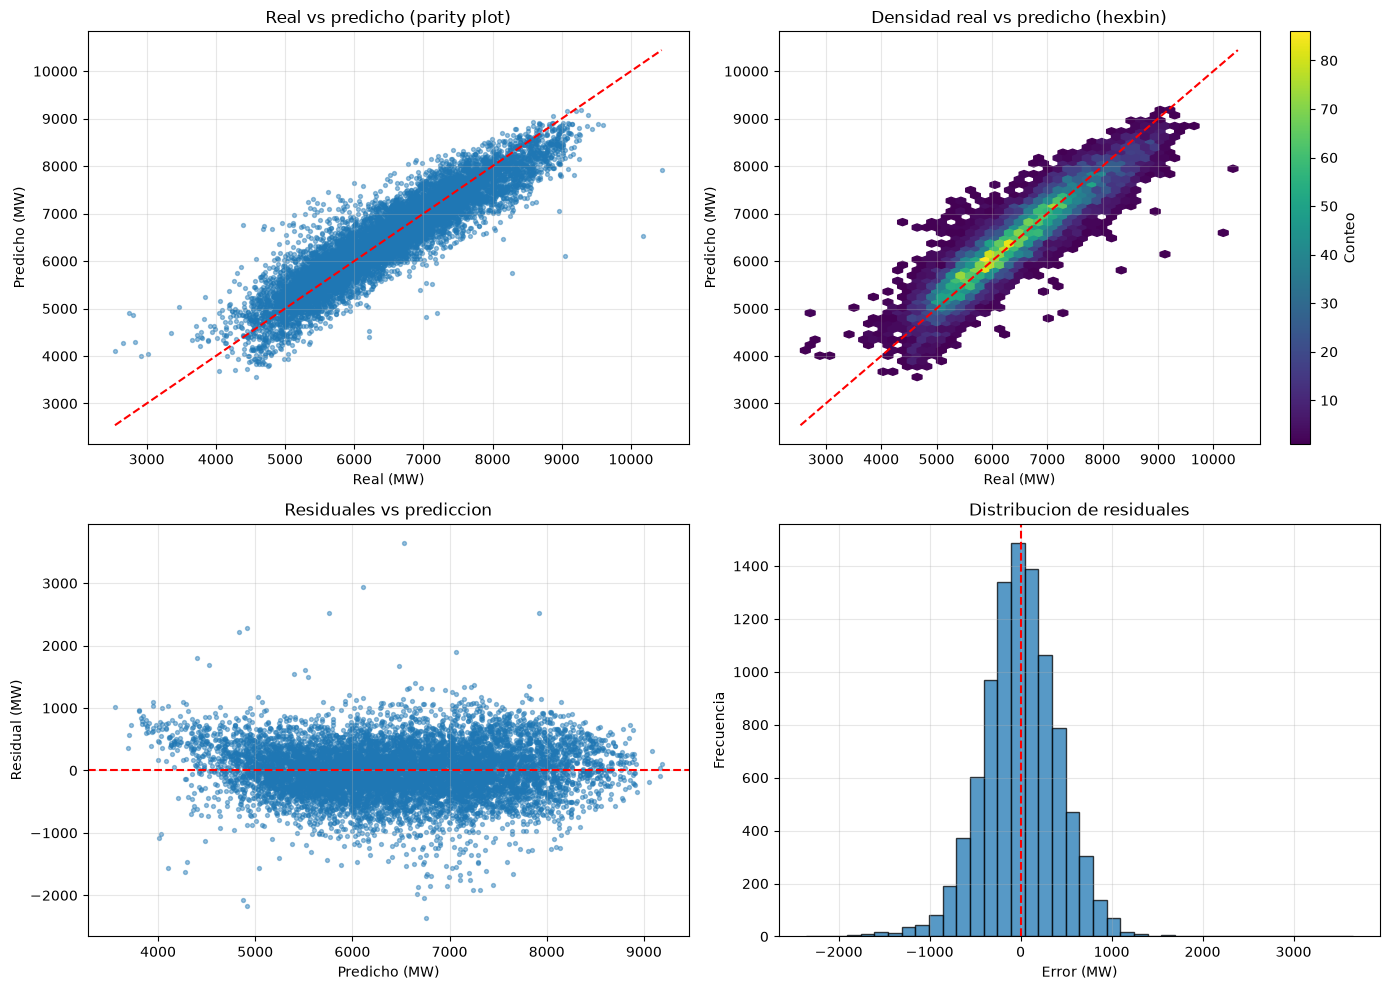

In [58]:
# Analisis de predicciones para split aleatorio (sin orden temporal)
pred_df = pd.DataFrame(index=y_test.index)
pred_df['Consumption'] = y_test
pred_df['pred_linear'] = pred_linear
pred_df['error_linear'] = pred_df['Consumption'] - pred_df['pred_linear']
pred_df['abs_error'] = pred_df['error_linear'].abs()

print('Resumen de error en test:')
print(pred_df[['error_linear', 'abs_error']].describe().round(3))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Parity plot: real vs predicho
axes[0, 0].scatter(pred_df['Consumption'], pred_df['pred_linear'], s=8, alpha=0.45)
min_v = min(pred_df['Consumption'].min(), pred_df['pred_linear'].min())
max_v = max(pred_df['Consumption'].max(), pred_df['pred_linear'].max())
axes[0, 0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
axes[0, 0].set_title('Real vs predicho (parity plot)')
axes[0, 0].set_xlabel('Real (MW)')
axes[0, 0].set_ylabel('Predicho (MW)')
axes[0, 0].grid(alpha=0.3)

# 2) Hexbin para densidad de puntos
hb = axes[0, 1].hexbin(
    pred_df['Consumption'],
    pred_df['pred_linear'],
    gridsize=45,
    cmap='viridis',
    mincnt=1
)
axes[0, 1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
axes[0, 1].set_title('Densidad real vs predicho (hexbin)')
axes[0, 1].set_xlabel('Real (MW)')
axes[0, 1].set_ylabel('Predicho (MW)')
axes[0, 1].grid(alpha=0.3)
fig.colorbar(hb, ax=axes[0, 1], label='Conteo')

# 3) Residuales vs prediccion
axes[1, 0].scatter(pred_df['pred_linear'], pred_df['error_linear'], s=8, alpha=0.45)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_title('Residuales vs prediccion')
axes[1, 0].set_xlabel('Predicho (MW)')
axes[1, 0].set_ylabel('Residual (MW)')
axes[1, 0].grid(alpha=0.3)

# 4) Histograma de residuales
axes[1, 1].hist(pred_df['error_linear'], bins=40, edgecolor='black', alpha=0.75)
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 1].set_title('Distribucion de residuales')
axes[1, 1].set_xlabel('Error (MW)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Analisis de coeficientes de la regresion lineal

A partir de los coeficientes estimados (`coef_df`, mostrado en la celda 6), se observan los siguientes patrones:

1. **Predominio de la estacionalidad horaria**
- Las variables dummy de `hour` aparecen entre los coeficientes de mayor magnitud absoluta.
- Esto indica que, manteniendo constantes las demas variables, la hora del dia explica una parte importante del nivel de `Consumption`.
- En terminos practicos, el modelo esta capturando correctamente el ciclo intradiario de demanda.

2. **Interpretacion del signo en variables dummy**
- Un coeficiente positivo en una dummy (por ejemplo, `hour_13`) implica que esa categoria tiende a elevar el consumo respecto a la categoria base omitida por el encoder (`drop='first'`).
- Un coeficiente negativo implicaria lo contrario: menor consumo relativo a la categoria base.

3. **Aporte de variables energeticas de origen**
- Variables como `Production`, `Oil and Gas`, `Coal` o `Hydroelectric` tambien aportan explicacion del consumo.
- Su interpretacion debe hacerse con cuidado porque pueden estar fuertemente correlacionadas entre si y con la propia dinamica temporal.

4. **Cautela: magnitud no siempre equivale a causalidad directa**
- En presencia de multicolinealidad (comun cuando se usan muchas dummies y variables energeticas relacionadas), los coeficientes pueden volverse inestables.
- Por ello, el analisis de coeficientes debe complementarse con metricas de desempeno (MAE, RMSE, R2, MAPE), validacion temporal y, si se requiere inferencia mas robusta, regularizacion (Ridge/Lasso).

5. **Conclusion del modelo actual**
- La regresion lineal esta capturando razonablemente bien la estructura del problema gracias a:
  - dummies temporales (hora/dia/mes/trimestre/anio),
  - `day_of_year` como tendencia estacional,
  - variables energeticas operativas del sistema.
- El resultado es consistente con el salto de desempeno observado frente a la version con features temporales mas simples.

## Diagnostico del modelo de regresion lineal

A continuacion se incluye un bloque de diagnosticos clasicos del modelo:
1. Colinealidad (VIF).
2. Heterocedasticidad (Breusch-Pagan).
3. Normalidad de residuales (Jarque-Bera).
4. Observaciones influyentes (leverage y Cook's distance).

### 1) Colinealidad: Variance Inflation Factor (VIF)

In [59]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Para evitar costo alto, calculamos VIF en una muestra representativa del train
vif_sample = X_train.sample(n=min(12000, len(X_train)), random_state=42)

vif_df = pd.DataFrame({
    'feature': vif_sample.columns,
    'VIF': [variance_inflation_factor(vif_sample.values, i) for i in range(vif_sample.shape[1])]
}).sort_values('VIF', ascending=False)

high_vif_5 = (vif_df['VIF'] > 5).sum()
high_vif_10 = (vif_df['VIF'] > 10).sum()

print(f'Features evaluadas: {len(vif_df)}')
print(f'Numero de features con VIF > 5: {high_vif_5}')
print(f'Numero de features con VIF > 10: {high_vif_10}')
display(vif_df.head(15))

C:\Users\abelv\AppData\Local\Temp\ipykernel_34748\1488866556.py:8: UserWarning: The design matrix is poorly conditioned (condition number=7.22e+15). VIF calculations may be numerically unstable.
  'VIF': [variance_inflation_factor(vif_sample.values, i) for i in range(vif_sample.shape[1])]
c:\Users\abelv\Documents\cursos\Elementos de IA\2026\Ch03\labs\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\abelv\Documents\cursos\Elementos de IA\2026\Ch03\labs\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\abelv\Documents\cursos\Elementos de IA\2026\Ch03\labs\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatr

Features evaluadas: 59
Numero de features con VIF > 5: 21
Numero de features con VIF > 10: 20


c:\Users\abelv\Documents\cursos\Elementos de IA\2026\Ch03\labs\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


,feature,VIF
49,quarter_2,5.042453e+06
40,month_4,4.990680e+06
46,month_10,2.306518e+06
47,month_11,2.009691e+06
48,month_12,1.736739e+06
41,month_5,1.611488e+06
51,quarter_4,9.966369e+05
43,month_7,9.267736e+05
42,month_6,7.262142e+05
45,month_9,6.374556e+05


**Analisis (colinealidad)**

Resultados observados en este notebook:
- Features evaluadas: 59.
- Variables con `VIF > 5`: 21.
- Variables con `VIF > 10`: 20.
- Statsmodels reporta matriz cercana a singular/rank-deficient.

Interpretacion:
- Existe colinealidad importante entre predictores, coherente con el uso de multiples dummies temporales y variables energeticas relacionadas.
- La capacidad predictiva puede seguir siendo buena, pero los coeficientes individuales son menos estables para inferencia causal.

Recomendacion:
- Si el objetivo principal es interpretabilidad de coeficientes, considerar Ridge/Lasso o reduccion de variables.

### 2) Heterocedasticidad: prueba de Breusch-Pagan

In [60]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Residuales sobre train para diagnosticos de supuestos del ajuste
train_pred = linear_model.predict(X_train)
train_residuals = y_train - train_pred

# Breusch-Pagan necesita matriz con constante
X_train_bp = sm.add_constant(X_train)
bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = het_breuschpagan(train_residuals, X_train_bp)

bp_results = pd.DataFrame({
    'estadistico': ['LM stat', 'LM p-value', 'F stat', 'F p-value'],
    'valor': [bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue]
})

display(bp_results)
print('Criterio: si p-value < 0.05, se rechaza homocedasticidad (hay heterocedasticidad).')

c:\Users\abelv\Documents\cursos\Elementos de IA\2026\Ch03\labs\.venv\Lib\site-packages\statsmodels\stats\diagnostic.py:1217: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resols = OLS(y, x).fit()


,estadistico,valor
0,LM stat,2903.286194
1,LM p-value,0.000000
2,F stat,55.437934
3,F p-value,0.000000


Criterio: si p-value < 0.05, se rechaza homocedasticidad (hay heterocedasticidad).


**Analisis (heterocedasticidad)**

Resultados observados:
- `LM stat = 2903.2862`, `LM p-value = 0.0000`.
- `F stat = 55.4379`, `F p-value = 0.0000`.

Interpretacion:
- Dado que los p-values son menores a 0.05, se rechaza homocedasticidad.
- Hay evidencia estadistica de heterocedasticidad en los errores del modelo.

Implicacion:
- Para prediccion el modelo puede ser util, pero para inferencia clasica conviene usar errores robustos (HC3) o un modelo alternativo con mejor especificacion de varianza.

### 3) Normalidad de residuales: prueba de Jarque-Bera

In [61]:
from statsmodels.stats.stattools import jarque_bera

jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(train_residuals)

jb_results = pd.DataFrame({
    'estadistico': ['JB stat', 'JB p-value', 'Skewness', 'Kurtosis'],
    'valor': [jb_stat, jb_pvalue, skew, kurtosis]
})
display(jb_results)
print('Criterio: si p-value < 0.05, se rechaza normalidad de residuales.')

,estadistico,valor
0,JB stat,9920.382945
1,JB p-value,0.000000
2,Skewness,0.018397
3,Kurtosis,5.326763


Criterio: si p-value < 0.05, se rechaza normalidad de residuales.


**Analisis (normalidad de residuales)**

Resultados observados:
- `JB stat = 9920.3829`, `JB p-value = 0.0000`.
- `Skewness = 0.0184` (asimetria baja).
- `Kurtosis = 5.3268` (colas mas pesadas que una normal, que tiene 3).

Interpretacion:
- Se rechaza normalidad estricta de residuales.
- Aunque la asimetria es pequena, la curtosis elevada indica presencia de eventos extremos/outliers.

Implicacion:
- En un contexto predictivo esto no invalida el modelo, pero explica por que aparecen errores grandes en algunos puntos.

### 4) Observaciones influyentes: leverage y Cook's distance (aprox.)

In [62]:
# Calculamos diagnosticos de influencia en una muestra de train para mantener costo computacional razonable
infl_sample = train_df.sample(n=min(12000, len(train_df)), random_state=42)
X_inf = infl_sample[FEATURES].to_numpy()
y_inf = infl_sample[TARGET].to_numpy()

# Prediccion del modelo ya entrenado y residuales en la muestra
y_inf_pred = linear_model.predict(infl_sample[FEATURES])
res_inf = y_inf - y_inf_pred

# Matriz para leverage: h_i = x_i^T (X'X)^-1 x_i (con intercepto)
X_inf_const = np.column_stack([np.ones(len(X_inf)), X_inf])
XtX_inv = np.linalg.pinv(X_inf_const.T @ X_inf_const)
leverages = np.einsum('ij,jk,ik->i', X_inf_const, XtX_inv, X_inf_const)

# Cook's distance aproximada
p = X_inf_const.shape[1]
mse_inf = np.mean(res_inf**2)
cooks_d = (res_inf**2 / (p * mse_inf)) * (leverages / (1 - leverages)**2)

# Umbrales habituales
lev_threshold = 2 * p / len(X_inf_const)
cook_threshold = 4 / len(X_inf_const)

influence_df = pd.DataFrame({
    'leverage': leverages,
    'cooks_d': cooks_d,
    'abs_residual': np.abs(res_inf)
}, index=infl_sample.index)

print(f'Muestras evaluadas: {len(influence_df)}')
print(f'Umbral leverage (2p/n): {lev_threshold:.6f}')
print(f'Umbral Cook D (4/n): {cook_threshold:.6f}')
print(f'Puntos con leverage alto: {(influence_df["leverage"] > lev_threshold).sum()}')
print(f'Puntos con Cook D alto: {(influence_df["cooks_d"] > cook_threshold).sum()}')

# Top observaciones influyentes por Cook's distance
display(influence_df.sort_values('cooks_d', ascending=False).head(10))

Muestras evaluadas: 12000
Umbral leverage (2p/n): 0.010000
Umbral Cook D (4/n): 0.000333
Puntos con leverage alto: 61
Puntos con Cook D alto: 472


,leverage,cooks_d,abs_residual
DateTime,,,
2025-11-27 04:00:00,0.014780,0.013310,3070.866263
2025-10-11 05:00:00,0.011304,0.012673,3438.515040
2025-10-11 02:00:00,0.009969,0.009616,3193.669363
2024-01-01 06:00:00,0.045729,0.007163,1240.482315
2025-08-08 06:00:00,0.007425,0.006698,3096.429405
2019-06-08 02:00:00,0.008060,0.004005,2296.635095
2025-05-26 04:00:00,0.004855,0.003039,2585.800638
2026-01-12 03:00:00,0.007574,0.002962,2038.384157
2024-01-01 08:00:00,0.007917,0.002922,1979.613736


**Analisis (observaciones influyentes)**

Resultados observados (muestra de 12,000 puntos de train):
- Umbral leverage: `2p/n = 0.010000`.
- Umbral Cook's D: `4/n = 0.000333`.
- Puntos con leverage alto: 61.
- Puntos con Cook's D alto: 472.

Interpretacion:
- Existe un subconjunto pequeno pero no despreciable de observaciones influyentes.
- Esto es consistente con picos/condiciones operativas extremas del sistema electrico.

Implicacion:
- Conviene monitorear estas observaciones y evaluar robustez del modelo (por ejemplo, regresion robusta o winsorizacion de extremos) si el objetivo operativo exige estabilidad en eventos atipicos.

## Seleccion de variables: Best Subset Selection

In [63]:
from itertools import combinations

# Best Subset Selection con busqueda exhaustiva en un conjunto prefiltrado para controlar costo computacional.
# 1) Prefiltro por correlacion absoluta con el target en train.
max_pool = 14
max_subset_size = 6

feature_rank = X_train.corrwith(y_train).abs().sort_values(ascending=False)
candidate_pool = feature_rank.head(max_pool).index.tolist()

print(f'Candidate pool ({len(candidate_pool)} features):')
print(candidate_pool)

# 2) Busqueda exhaustiva de subconjuntos de tamano 1..max_subset_size,
#    evaluando por RMSE en validation.
search_records = []

for k in range(1, max_subset_size + 1):
    for subset in combinations(candidate_pool, k):
        subset = list(subset)

        model_k = LinearRegression()
        model_k.fit(X_train[subset], y_train)

        pred_val_k = model_k.predict(X_val[subset])
        rmse_val_k = np.sqrt(mean_squared_error(y_val, pred_val_k))
        r2_val_k = r2_score(y_val, pred_val_k)

        search_records.append({
            'k': k,
            'subset': subset,
            'rmse_val': rmse_val_k,
            'r2_val': r2_val_k
        })

subset_results = pd.DataFrame(search_records).sort_values(['rmse_val', 'k'], ascending=[True, True]).reset_index(drop=True)

best_subset_features = subset_results.loc[0, 'subset']
best_subset_k = subset_results.loc[0, 'k']
best_subset_rmse_val = subset_results.loc[0, 'rmse_val']
best_subset_r2_val = subset_results.loc[0, 'r2_val']

print('\nMejor subset encontrado (criterio: menor RMSE en validation):')
print(f'k = {best_subset_k}')
print('Features seleccionadas:', best_subset_features)
print(f'RMSE validation = {best_subset_rmse_val:.4f}')
print(f'R2 validation = {best_subset_r2_val:.4f}')

# 3) Evaluacion final del subset seleccionado en test
best_subset_model = LinearRegression()
best_subset_model.fit(X_train[best_subset_features], y_train)

pred_test_best_subset = best_subset_model.predict(X_test[best_subset_features])

best_subset_test_metrics = pd.DataFrame([
    {
        'modelo': 'LinearRegression (Best Subset)',
        'n_features': len(best_subset_features),
        'MAE_test': mean_absolute_error(y_test, pred_test_best_subset),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, pred_test_best_subset)),
        'R2_test': r2_score(y_test, pred_test_best_subset),
        'MAPE_test_%': np.mean(np.abs((y_test - pred_test_best_subset) / y_test)) * 100
    }
])

print('\nTop 10 subsets por RMSE en validation:')
display(subset_results.head(10))

print('\nMetricas en test del mejor subset:')
display(best_subset_test_metrics.round(4))

Candidate pool (14 features):
['Production', 'Oil and Gas', 'Coal', 'Biomass', 'Hydroelectric', 'day_of_week_6', 'quarter_2', 'hour_3', 'hour_4', 'hour_2', 'month_2', 'year_2021', 'month_5', 'hour_5']

Mejor subset encontrado (criterio: menor RMSE en validation):
k = 6
Features seleccionadas: ['Production', 'Oil and Gas', 'Coal', 'Hydroelectric', 'day_of_week_6', 'hour_3']
RMSE validation = 648.8537
R2 validation = 0.6268

Top 10 subsets por RMSE en validation:


,k,subset,rmse_val,r2_val
0,6,"[Production, Oil and Gas, Coal, Hydroelectric,...",648.853703,0.626807
1,6,"[Production, Oil and Gas, Coal, Hydroelectric,...",649.496797,0.626067
2,6,"[Production, Oil and Gas, Coal, Hydroelectric,...",650.754141,0.624617
3,6,"[Production, Oil and Gas, Coal, Hydroelectric,...",651.649809,0.623583
4,6,"[Production, Oil and Gas, Coal, Hydroelectric,...",651.921719,0.623269
5,6,"[Production, Oil and Gas, Coal, Hydroelectric,...",652.218669,0.622926
6,6,"[Production, Oil and Gas, Coal, Hydroelectric,...",652.957616,0.622071
7,6,"[Production, Oil and Gas, Coal, Biomass, Hydro...",652.963480,0.622064
8,6,"[Production, Oil and Gas, Coal, Hydroelectric,...",654.195137,0.620637
9,6,"[Production, Oil and Gas, Coal, day_of_week_6,...",654.411323,0.620386



Metricas en test del mejor subset:


,modelo,n_features,MAE_test,RMSE_test,R2_test,MAPE_test_%
0,LinearRegression (Best Subset),6,509.4263,633.7064,0.6475,8.1282


### Analisis de variables seleccionadas (Best Subset)

Resultados del metodo:
- Pool evaluado: 14 variables prefiltradas por correlacion en train.
- Busqueda exhaustiva evaluada para tamanos `k = 1..6`.
- Mejor subset (por menor RMSE en validation):
  - `['Production', 'Oil and Gas', 'Coal', 'Hydroelectric', 'day_of_week_6', 'hour_3']`
  - `k = 6`
  - `RMSE validation = 648.8537`
  - `R2 validation = 0.6268`

Interpretacion tecnica:
1. **Variables energeticas dominantes**
- El subset retiene 4 variables de oferta (`Production`, `Oil and Gas`, `Coal`, `Hydroelectric`), lo cual sugiere que gran parte de la variabilidad de `Consumption` se asocia con el estado operativo del sistema electrico.

2. **Componente temporal minima pero relevante**
- El metodo conserva `day_of_week_6` y `hour_3`, indicando que incluso con pocas dummies, la estacionalidad semanal e intradiaria aporta señal util.

3. **Parcimonia vs desempeno**
- El subset de 6 variables es mas interpretable y compacto, pero en este caso rinde peor que el modelo completo (que usaba todas las features ingenierizadas).
- Metricas del subset en test: `RMSE = 633.7064`, `R2 = 0.6475`, `MAPE = 8.1282%`.

Conclusion:
- Best Subset identifica un nucleo de variables explicativas claras, util para interpretabilidad y simplificacion.
- Si el objetivo prioritario es precision predictiva, conviene mantener el modelo completo o usar regularizacion para balancear complejidad y generalizacion.

## Seleccion de variables: Forward Selection (greedy)

Objetivo:
- Construir un subset de variables de forma incremental, agregando en cada paso la variable que mas reduce el RMSE en validacion.

Criterio del metodo:
- Pool inicial: top variables por correlacion absoluta con `Consumption` en train.
- Regla de avance: se agrega solo si hay mejora minima de RMSE.
- Regla de parada: cuando no hay mejora suficiente o se alcanza el maximo de pasos.

In [67]:
# Forward Selection (greedy) con RMSE en validation como criterio.
# Se trabaja sobre un pool prefiltrado para mantener bajo el costo computacional.

max_pool_forward = 20
max_steps_forward = 10
min_improvement = 1e-4

# 1) Definir pool candidato
forward_pool = (
    X_train.corrwith(y_train)
    .abs()
    .sort_values(ascending=False)
    .head(max_pool_forward)
    .index
    .tolist()
)

selected_forward = []
remaining_forward = forward_pool.copy()
best_rmse_forward = np.inf
forward_history = []

# 2) Busqueda greedy por pasos
for step in range(1, max_steps_forward + 1):
    best_feature_step = None
    best_rmse_step = np.inf
    best_r2_step = -np.inf

    for feature in remaining_forward:
        trial_features = selected_forward + [feature]

        model_trial = LinearRegression()
        model_trial.fit(X_train[trial_features], y_train)

        pred_val_trial = model_trial.predict(X_val[trial_features])
        rmse_trial = np.sqrt(mean_squared_error(y_val, pred_val_trial))
        r2_trial = r2_score(y_val, pred_val_trial)

        if rmse_trial < best_rmse_step:
            best_rmse_step = rmse_trial
            best_r2_step = r2_trial
            best_feature_step = feature

    improvement = best_rmse_forward - best_rmse_step

    if best_feature_step is None or improvement <= min_improvement:
        break

    selected_forward.append(best_feature_step)
    remaining_forward.remove(best_feature_step)
    best_rmse_forward = best_rmse_step

    forward_history.append({
        "step": step,
        "feature_added": best_feature_step,
        "n_features": len(selected_forward),
        "rmse_val": best_rmse_step,
        "r2_val": best_r2_step,
        "improvement_rmse": improvement,
    })

forward_history_df = pd.DataFrame(forward_history)

# 3) Entrenar modelo final con el subset seleccionado
forward_model = LinearRegression()
forward_model.fit(X_train[selected_forward], y_train)

pred_test_forward = forward_model.predict(X_test[selected_forward])

forward_test_metrics = pd.DataFrame([
    {
        "modelo": "LinearRegression (Forward Selection)",
        "n_features": len(selected_forward),
        "MAE_test": mean_absolute_error(y_test, pred_test_forward),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, pred_test_forward)),
        "R2_test": r2_score(y_test, pred_test_forward),
        "MAPE_test_%": np.mean(np.abs((y_test - pred_test_forward) / y_test)) * 100,
    }
])

# 4) Resumen organizado de resultados
forward_selected_df = pd.DataFrame({
    "orden": range(1, len(selected_forward) + 1),
    "feature": selected_forward,
})

print("Forward pool inicial (top por correlacion):")
print(forward_pool)

print("\nVariables seleccionadas por orden de entrada:")
display(forward_selected_df)

print("\nHistoria de seleccion (validation):")
display(forward_history_df.round(4))

print("\nMetricas en test del modelo Forward Selection:")
display(forward_test_metrics.round(4))

Forward pool inicial (top por correlacion):
['Production', 'Oil and Gas', 'Coal', 'Biomass', 'Hydroelectric', 'day_of_week_6', 'quarter_2', 'hour_3', 'hour_4', 'hour_2', 'month_2', 'year_2021', 'month_5', 'hour_5', 'hour_1', 'hour_20', 'Nuclear', 'hour_19', 'year_2023', 'quarter_3']

Variables seleccionadas por orden de entrada:


,orden,feature
0,1,Production
1,2,Oil and Gas
2,3,Coal
3,4,Hydroelectric
4,5,year_2023
5,6,day_of_week_6
6,7,hour_3
7,8,hour_4
8,9,hour_2
9,10,hour_5



Historia de seleccion (validation):


,step,feature_added,n_features,rmse_val,r2_val,improvement_rmse
0,1,Production,1,769.4217,0.4752,inf
1,2,Oil and Gas,2,736.1162,0.5197,33.3055
2,3,Coal,3,704.3993,0.5602,31.7169
3,4,Hydroelectric,4,677.1522,0.5935,27.2471
4,5,year_2023,5,656.9362,0.6175,20.2160
5,6,day_of_week_6,6,642.1017,0.6345,14.8345
6,7,hour_3,7,629.1215,0.6492,12.9801
7,8,hour_4,8,614.6982,0.6651,14.4234
8,9,hour_2,9,599.3140,0.6816,15.3841
9,10,hour_5,10,582.6103,0.6991,16.7038



Metricas en test del modelo Forward Selection:


,modelo,n_features,MAE_test,RMSE_test,R2_test,MAPE_test_%
0,LinearRegression (Forward Selection),10,454.3312,568.4568,0.7164,7.2238


### Analisis de Forward Selection

Lectura de resultados:
1. Revisar la tabla de orden de entrada para identificar que variables aportan primero (senal principal).
2. Revisar la historia de seleccion para confirmar que el RMSE de validacion disminuye de forma estable.
3. Validar en test si el subset mantiene buena generalizacion frente al modelo completo.

Interpretacion esperada:
- Si las primeras variables son energeticas (por ejemplo, `Production`, `Oil and Gas`, `Coal`, `Hydroelectric`), entonces la mayor parte de la explicacion de `Consumption` proviene de la estructura de oferta.
- Si luego aparecen dummies de hora/dia/anio, estas variables suelen capturar estacionalidad fina y mejorar el ajuste marginal.
- Si el RMSE en test sube poco frente al modelo completo, el subset es una buena alternativa por parsimonia e interpretabilidad.

Conclusiones practicas:
- Forward Selection es util para construir un modelo lineal mas compacto sin buscar exhaustivamente todas las combinaciones.
- La decision final debe balancear precision (RMSE/R2 en test) e interpretabilidad (numero de variables y sentido fisico).

## Seleccion de variables: Backward Selection (greedy)

In [65]:
# Backward Selection (greedy) con criterio RMSE en validation.
# Inicia con un pool prefiltrado y elimina la variable cuya remocion mejora (o menos deteriora) RMSE.

max_pool_backward = 20
min_features_backward = 5
min_improvement_backward = 1e-4

backward_pool = X_train.corrwith(y_train).abs().sort_values(ascending=False).head(max_pool_backward).index.tolist()
selected_backward = backward_pool.copy()

# RMSE base con todas las variables del pool
base_model = LinearRegression()
base_model.fit(X_train[selected_backward], y_train)
base_pred_val = base_model.predict(X_val[selected_backward])
best_rmse_backward = np.sqrt(mean_squared_error(y_val, base_pred_val))
best_r2_backward = r2_score(y_val, base_pred_val)

backward_history = [{
    'step': 0,
    'feature_removed': None,
    'n_features': len(selected_backward),
    'rmse_val': best_rmse_backward,
    'r2_val': best_r2_backward,
    'improvement_rmse': 0.0
}]

step = 0
while len(selected_backward) > min_features_backward:
    step += 1
    best_feature_remove = None
    best_rmse_step = np.inf
    best_r2_step = -np.inf

    for feature in selected_backward:
        trial_features = [f for f in selected_backward if f != feature]

        model_trial = LinearRegression()
        model_trial.fit(X_train[trial_features], y_train)

        pred_val_trial = model_trial.predict(X_val[trial_features])
        rmse_trial = np.sqrt(mean_squared_error(y_val, pred_val_trial))
        r2_trial = r2_score(y_val, pred_val_trial)

        if rmse_trial < best_rmse_step:
            best_rmse_step = rmse_trial
            best_r2_step = r2_trial
            best_feature_remove = feature

    improvement = best_rmse_backward - best_rmse_step

    # Si no hay mejora suficiente, detenemos
    if best_feature_remove is None or improvement <= min_improvement_backward:
        break

    selected_backward.remove(best_feature_remove)
    best_rmse_backward = best_rmse_step

    backward_history.append({
        'step': step,
        'feature_removed': best_feature_remove,
        'n_features': len(selected_backward),
        'rmse_val': best_rmse_step,
        'r2_val': best_r2_step,
        'improvement_rmse': improvement
    })

backward_history_df = pd.DataFrame(backward_history)

# Entrenamiento final con el subset seleccionado por backward
backward_model = LinearRegression()
backward_model.fit(X_train[selected_backward], y_train)

pred_test_backward = backward_model.predict(X_test[selected_backward])

backward_test_metrics = pd.DataFrame([
    {
        'modelo': 'LinearRegression (Backward Selection)',
        'n_features': len(selected_backward),
        'MAE_test': mean_absolute_error(y_test, pred_test_backward),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, pred_test_backward)),
        'R2_test': r2_score(y_test, pred_test_backward),
        'MAPE_test_%': np.mean(np.abs((y_test - pred_test_backward) / y_test)) * 100
    }
])

print('Backward pool inicial:')
print(backward_pool)

print('\nVariables finales seleccionadas por Backward Selection:')
print(selected_backward)

print('\nHistoria de eliminacion (por paso):')
display(backward_history_df)

print('\nMetricas en test del modelo seleccionado:')
display(backward_test_metrics.round(4))

Backward pool inicial:
['Production', 'Oil and Gas', 'Coal', 'Biomass', 'Hydroelectric', 'day_of_week_6', 'quarter_2', 'hour_3', 'hour_4', 'hour_2', 'month_2', 'year_2021', 'month_5', 'hour_5', 'hour_1', 'hour_20', 'Nuclear', 'hour_19', 'year_2023', 'quarter_3']

Variables finales seleccionadas por Backward Selection:
['Production', 'Oil and Gas', 'Coal', 'Biomass', 'Hydroelectric', 'day_of_week_6', 'quarter_2', 'hour_3', 'hour_4', 'hour_2', 'month_2', 'year_2021', 'month_5', 'hour_5', 'hour_1', 'hour_20', 'Nuclear', 'hour_19', 'year_2023', 'quarter_3']

Historia de eliminacion (por paso):


,step,feature_removed,n_features,rmse_val,r2_val,improvement_rmse
0,0,None,20,535.155927,0.746136,0.0



Metricas en test del modelo seleccionado:


,modelo,n_features,MAE_test,RMSE_test,R2_test,MAPE_test_%
0,LinearRegression (Backward Selection),20,409.1508,519.8268,0.7628,6.506


### Analisis de variables seleccionadas (Backward Selection)

Resultados observados:
- Pool inicial: 20 variables prefiltradas por correlacion en train.
- Resultado del algoritmo: **no elimino ninguna variable**.
- Historia de eliminacion: solo paso base (`step = 0`), con:
  - `RMSE validation = 535.1559`
  - `R2 validation = 0.7461`
- Metricas en test del modelo final:
  - `n_features = 20`
  - `RMSE test = 519.8268`
  - `R2 test = 0.7628`
  - `MAPE test = 6.5060%`

Interpretacion tecnica:
1. **Cada variable del pool aporta valor marginal**
- Bajo el criterio definido (mejora minima de RMSE), quitar cualquier variable del conjunto inicial empeora o no mejora el desempeno en validation.

2. **Comportamiento coherente con variables complementarias**
- El pool mezcla variables energeticas y dummies temporales; es esperable que la contribucion conjunta sea mejor que eliminarlas individualmente.

3. **Implicacion practica**
- En este experimento, Backward Selection no reduce dimensionalidad sin costo de precision.
- Si se quiere mayor parsimonia, conviene relajar el criterio de parada o usar regularizacion (Ridge/Lasso) para comprimir coeficientes sin eliminar variables de forma discreta.

## Seleccion de variables: Stepwise Forward Selection

In [66]:
# Stepwise Forward Selection:
# 1) Forward: agrega la mejor variable por RMSE en validation.
# 2) Backward interno: despues de agregar, intenta eliminar variables seleccionadas si mejora RMSE.

max_pool_stepwise = 20
max_features_stepwise = 12
min_improvement_stepwise = 1e-4

stepwise_pool = X_train.corrwith(y_train).abs().sort_values(ascending=False).head(max_pool_stepwise).index.tolist()
selected_stepwise = []
remaining_stepwise = stepwise_pool.copy()

best_rmse_stepwise = np.inf
stepwise_history = []
iteration = 0

while len(selected_stepwise) < max_features_stepwise and len(remaining_stepwise) > 0:
    iteration += 1

    # ----- Forward step -----
    best_feature_add = None
    best_rmse_add = np.inf
    best_r2_add = -np.inf

    for feature in remaining_stepwise:
        trial_features = selected_stepwise + [feature]

        model_trial = LinearRegression()
        model_trial.fit(X_train[trial_features], y_train)

        pred_val_trial = model_trial.predict(X_val[trial_features])
        rmse_trial = np.sqrt(mean_squared_error(y_val, pred_val_trial))
        r2_trial = r2_score(y_val, pred_val_trial)

        if rmse_trial < best_rmse_add:
            best_rmse_add = rmse_trial
            best_r2_add = r2_trial
            best_feature_add = feature

    improvement_add = best_rmse_stepwise - best_rmse_add

    if best_feature_add is None or improvement_add <= min_improvement_stepwise:
        break

    selected_stepwise.append(best_feature_add)
    remaining_stepwise.remove(best_feature_add)
    best_rmse_stepwise = best_rmse_add

    stepwise_history.append({
        'iter': iteration,
        'action': 'add',
        'feature': best_feature_add,
        'n_features': len(selected_stepwise),
        'rmse_val': best_rmse_add,
        'r2_val': best_r2_add,
        'improvement_rmse': improvement_add
    })

    # ----- Backward check (stepwise part) -----
    backward_improved = True
    while backward_improved and len(selected_stepwise) > 1:
        backward_improved = False

        best_feature_remove = None
        best_rmse_remove = best_rmse_stepwise
        best_r2_remove = None

        for feature in selected_stepwise:
            trial_features = [f for f in selected_stepwise if f != feature]

            model_trial = LinearRegression()
            model_trial.fit(X_train[trial_features], y_train)

            pred_val_trial = model_trial.predict(X_val[trial_features])
            rmse_trial = np.sqrt(mean_squared_error(y_val, pred_val_trial))
            r2_trial = r2_score(y_val, pred_val_trial)

            if rmse_trial < best_rmse_remove - min_improvement_stepwise:
                best_rmse_remove = rmse_trial
                best_r2_remove = r2_trial
                best_feature_remove = feature

        if best_feature_remove is not None:
            selected_stepwise.remove(best_feature_remove)
            remaining_stepwise.append(best_feature_remove)
            improvement_remove = best_rmse_stepwise - best_rmse_remove
            best_rmse_stepwise = best_rmse_remove
            backward_improved = True

            stepwise_history.append({
                'iter': iteration,
                'action': 'remove',
                'feature': best_feature_remove,
                'n_features': len(selected_stepwise),
                'rmse_val': best_rmse_remove,
                'r2_val': best_r2_remove,
                'improvement_rmse': improvement_remove
            })

stepwise_history_df = pd.DataFrame(stepwise_history)

# Entrenamiento final con subset stepwise
stepwise_model = LinearRegression()
stepwise_model.fit(X_train[selected_stepwise], y_train)

pred_test_stepwise = stepwise_model.predict(X_test[selected_stepwise])

stepwise_test_metrics = pd.DataFrame([
    {
        'modelo': 'LinearRegression (Stepwise Forward)',
        'n_features': len(selected_stepwise),
        'MAE_test': mean_absolute_error(y_test, pred_test_stepwise),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, pred_test_stepwise)),
        'R2_test': r2_score(y_test, pred_test_stepwise),
        'MAPE_test_%': np.mean(np.abs((y_test - pred_test_stepwise) / y_test)) * 100
    }
])

print('Stepwise pool inicial:')
print(stepwise_pool)

print('\nVariables finales seleccionadas (Stepwise Forward):')
print(selected_stepwise)

print('\nHistoria de seleccion stepwise:')
display(stepwise_history_df)

print('\nMetricas en test del modelo stepwise:')
display(stepwise_test_metrics.round(4))

Stepwise pool inicial:
['Production', 'Oil and Gas', 'Coal', 'Biomass', 'Hydroelectric', 'day_of_week_6', 'quarter_2', 'hour_3', 'hour_4', 'hour_2', 'month_2', 'year_2021', 'month_5', 'hour_5', 'hour_1', 'hour_20', 'Nuclear', 'hour_19', 'year_2023', 'quarter_3']

Variables finales seleccionadas (Stepwise Forward):
['Production', 'Oil and Gas', 'Coal', 'Hydroelectric', 'year_2023', 'day_of_week_6', 'hour_3', 'hour_4', 'hour_2', 'hour_5', 'hour_1', 'Nuclear']

Historia de seleccion stepwise:


,iter,action,feature,n_features,rmse_val,r2_val,improvement_rmse
0,1,add,Production,1,769.421669,0.475230,inf
1,2,add,Oil and Gas,2,736.116152,0.519678,33.305517
2,3,add,Coal,3,704.399264,0.560177,31.716888
3,4,add,Hydroelectric,4,677.152171,0.593545,27.247094
4,5,add,year_2023,5,656.936184,0.617451,20.215987
5,6,add,day_of_week_6,6,642.101659,0.634533,14.834524
6,7,add,hour_3,7,629.121520,0.649160,12.980139
7,8,add,hour_4,8,614.698156,0.665062,14.423364
8,9,add,hour_2,9,599.314038,0.681618,15.384118
9,10,add,hour_5,10,582.610250,0.699118,16.703788



Metricas en test del modelo stepwise:


,modelo,n_features,MAE_test,RMSE_test,R2_test,MAPE_test_%
0,LinearRegression (Stepwise Forward),12,426.8242,539.5298,0.7445,6.7881


### Validacion cruzada del modelo StepForward seleccionado

En este bloque se estima la capacidad predictiva del subset:
`['Production', 'Oil and Gas', 'Coal', 'Hydroelectric', 'year_2023', 'day_of_week_6', 'hour_3', 'hour_4', 'hour_2', 'hour_5', 'hour_1', 'Nuclear']`

Configuracion:
- Metodo: `KFold` con `5` particiones.
- Mezcla aleatoria: `shuffle=True`, `random_state=42`.
- Metricas reportadas por fold y en resumen: `MAE`, `RMSE`, `R2`, `MAPE_%`.

Interpretacion:
- La media de folds aproxima el desempeno esperado fuera de muestra.
- La desviacion estandar indica estabilidad del modelo entre particiones.

In [68]:
# Validacion cruzada para el subset seleccionado por StepForward
from sklearn.model_selection import KFold, cross_validate

stepforward_selected_features = [
    'Production', 'Oil and Gas', 'Coal', 'Hydroelectric',
    'year_2023', 'day_of_week_6', 'hour_3', 'hour_4',
    'hour_2', 'hour_5', 'hour_1', 'Nuclear'
]

missing_features = [f for f in stepforward_selected_features if f not in model_df.columns]
if missing_features:
    raise ValueError(f'Faltan features en model_df: {missing_features}')

X_cv = model_df[stepforward_selected_features]
y_cv = model_df[TARGET]

# 5-fold CV con mezcla aleatoria para estimar generalizacion promedio
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2',
    'MAPE': 'neg_mean_absolute_percentage_error'
}

cv_scores = cross_validate(
    estimator=LinearRegression(),
    X=X_cv,
    y=y_cv,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

cv_folds_df = pd.DataFrame({
    'fold': np.arange(1, cv.get_n_splits() + 1),
    'MAE': -cv_scores['test_MAE'],
    'RMSE': -cv_scores['test_RMSE'],
    'R2': cv_scores['test_R2'],
    'MAPE_%': -cv_scores['test_MAPE'] * 100
})

cv_summary_stepforward = pd.DataFrame([{
    'modelo': 'LinearRegression (StepForward subset)',
    'n_features': len(stepforward_selected_features),
    'CV_folds': cv.get_n_splits(),
    'MAE_mean': cv_folds_df['MAE'].mean(),
    'MAE_std': cv_folds_df['MAE'].std(ddof=1),
    'RMSE_mean': cv_folds_df['RMSE'].mean(),
    'RMSE_std': cv_folds_df['RMSE'].std(ddof=1),
    'R2_mean': cv_folds_df['R2'].mean(),
    'R2_std': cv_folds_df['R2'].std(ddof=1),
    'MAPE_mean_%': cv_folds_df['MAPE_%'].mean(),
    'MAPE_std_%': cv_folds_df['MAPE_%'].std(ddof=1)
}])

print('Subset StepForward evaluado:')
print(stepforward_selected_features)

print('\nMetricas por fold (5-fold CV):')
display(cv_folds_df.round(4))

print('\nResumen CV (media y desviacion estandar):')
display(cv_summary_stepforward.round(4))

Subset StepForward evaluado:
['Production', 'Oil and Gas', 'Coal', 'Hydroelectric', 'year_2023', 'day_of_week_6', 'hour_3', 'hour_4', 'hour_2', 'hour_5', 'hour_1', 'Nuclear']

Metricas por fold (5-fold CV):


,fold,MAE,RMSE,R2,MAPE_%
0,1,432.3882,546.4055,0.7372,6.8791
1,2,434.6912,550.3838,0.7312,6.8742
2,3,433.3444,548.4168,0.7348,6.8841
3,4,433.8694,549.7516,0.7289,6.8885
4,5,435.6344,549.5131,0.7333,6.8932



Resumen CV (media y desviacion estandar):


,modelo,n_features,CV_folds,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,MAPE_mean_%,MAPE_std_%
0,LinearRegression (StepForward subset),12,5,433.9855,1.2443,548.8942,1.5619,0.7331,0.0032,6.8838,0.0075


### Analisis de variables seleccionadas (Stepwise Forward)

Resumen del metodo:
- En cada iteracion se agrega la variable que mas reduce RMSE en validation.
- Luego se revisa si alguna variable ya seleccionada debe salir (paso backward local).
- Esto combina flexibilidad del stepwise con eficiencia del enfoque forward.

Interpretacion esperada:
- Si no hay removals, el proceso se comporta como forward puro.
- Si aparecen removals, indica que algunas variables pierden utilidad al cambiar el contexto del subset.
- El subset final busca equilibrio entre precision y parsimonia.

## Bootstrap no parametrico de coeficientes (modelo StepForward seleccionado)

Objetivo:
- Estimar la variabilidad muestral de los coeficientes del modelo lineal usando remuestreo con reemplazo (bootstrap no parametrico).

Modelo evaluado:
- `Production`, `Oil and Gas`, `Coal`, `Hydroelectric`, `year_2023`, `day_of_week_6`, `hour_3`, `hour_4`, `hour_2`, `hour_5`, `hour_1`, `Nuclear`.

Salida principal:
- Distribucion bootstrap de cada coeficiente.
- Resumen con media, desvio estandar, mediana e IC percentil 95% (`p2.5`, `p97.5`).
- Indicador de estabilidad de signo (`prob_positivo`) y si el IC excluye cero (`ic_excluye_0`).

In [69]:
# Bootstrap no parametrico para coeficientes del modelo seleccionado
bootstrap_features = [
    'Production', 'Oil and Gas', 'Coal', 'Hydroelectric',
    'year_2023', 'day_of_week_6', 'hour_3', 'hour_4',
    'hour_2', 'hour_5', 'hour_1', 'Nuclear'
]

missing_boot_features = [f for f in bootstrap_features if f not in model_df.columns]
if missing_boot_features:
    raise ValueError(f'Faltan columnas para bootstrap: {missing_boot_features}')

X_boot = model_df[bootstrap_features].to_numpy()
y_boot = model_df[TARGET].to_numpy()
n = X_boot.shape[0]

n_bootstrap = 500
rng = np.random.default_rng(42)

coef_samples = np.empty((n_bootstrap, len(bootstrap_features) + 1), dtype=float)

for b in range(n_bootstrap):
    idx = rng.integers(0, n, size=n)
    X_b = X_boot[idx]
    y_b = y_boot[idx]

    model_b = LinearRegression()
    model_b.fit(X_b, y_b)

    coef_samples[b, 0] = model_b.intercept_
    coef_samples[b, 1:] = model_b.coef_

coef_names = ['intercepto'] + bootstrap_features
coef_boot_df = pd.DataFrame(coef_samples, columns=coef_names)

coef_boot_summary = pd.DataFrame({
    'coeficiente': coef_names,
    'mean': coef_boot_df.mean().values,
    'std': coef_boot_df.std(ddof=1).values,
    'median': coef_boot_df.median().values,
    'p2.5': coef_boot_df.quantile(0.025).values,
    'p97.5': coef_boot_df.quantile(0.975).values,
    'prob_positivo': (coef_boot_df > 0).mean().values,
})

coef_boot_summary['ic_excluye_0'] = (
    (coef_boot_summary['p2.5'] > 0) | (coef_boot_summary['p97.5'] < 0)
)

coef_boot_summary = coef_boot_summary.sort_values('coeficiente').reset_index(drop=True)

print(f'Bootstrap ejecutado con {n_bootstrap} replicas y n={n} observaciones por replica.')
print('Resumen bootstrap de coeficientes:')
display(coef_boot_summary.round(4))

# Version enfocada sin intercepto para lectura rapida
display(
    coef_boot_summary
    .query("coeficiente != 'intercepto'")
    .sort_values('std', ascending=False)
    .reset_index(drop=True)
    .round(4)
)

Bootstrap ejecutado con 500 replicas y n=62810 observaciones por replica.
Resumen bootstrap de coeficientes:


,coeficiente,mean,std,median,p2.5,p97.5,prob_positivo,ic_excluye_0
0,Coal,0.7290,0.0071,0.7290,0.7150,0.7419,1.0,True
1,Hydroelectric,0.3838,0.0046,0.3836,0.3747,0.3931,1.0,True
2,Nuclear,0.4714,0.0099,0.4721,0.4508,0.4888,1.0,True
3,Oil and Gas,0.7622,0.0063,0.7625,0.7508,0.7737,1.0,True
4,Production,0.2166,0.0034,0.2166,0.2102,0.2233,1.0,True
5,day_of_week_6,-477.5880,6.2417,-477.5305,-489.3803,-465.4636,0.0,True
6,hour_1,-774.0171,8.7106,-773.9607,-790.3782,-757.5758,0.0,True
7,hour_2,-846.0663,9.3772,-846.5825,-862.8168,-828.1141,0.0,True
8,hour_3,-876.3158,9.5807,-876.7434,-894.0806,-855.8304,0.0,True
9,hour_4,-842.0115,9.0710,-842.4777,-859.0659,-823.3582,0.0,True


,coeficiente,mean,std,median,p2.5,p97.5,prob_positivo,ic_excluye_0
0,hour_3,-876.3158,9.5807,-876.7434,-894.0806,-855.8304,0.0,True
1,hour_5,-751.2441,9.4181,-751.1621,-769.1759,-732.9300,0.0,True
2,hour_2,-846.0663,9.3772,-846.5825,-862.8168,-828.1141,0.0,True
3,hour_4,-842.0115,9.0710,-842.4777,-859.0659,-823.3582,0.0,True
4,hour_1,-774.0171,8.7106,-773.9607,-790.3782,-757.5758,0.0,True
5,year_2023,-441.1960,6.7409,-441.3047,-453.8052,-427.4756,0.0,True
6,day_of_week_6,-477.5880,6.2417,-477.5305,-489.3803,-465.4636,0.0,True
7,Nuclear,0.4714,0.0099,0.4721,0.4508,0.4888,1.0,True
8,Coal,0.7290,0.0071,0.7290,0.7150,0.7419,1.0,True
9,Oil and Gas,0.7622,0.0063,0.7625,0.7508,0.7737,1.0,True


### Visualizacion de intervalos bootstrap por coeficiente

El siguiente grafico muestra para cada coeficiente:
- Punto central: media bootstrap.
- Barra horizontal: intervalo percentil 95% (`p2.5` a `p97.5`).
- Linea vertical en 0 para evaluar cambio de signo.

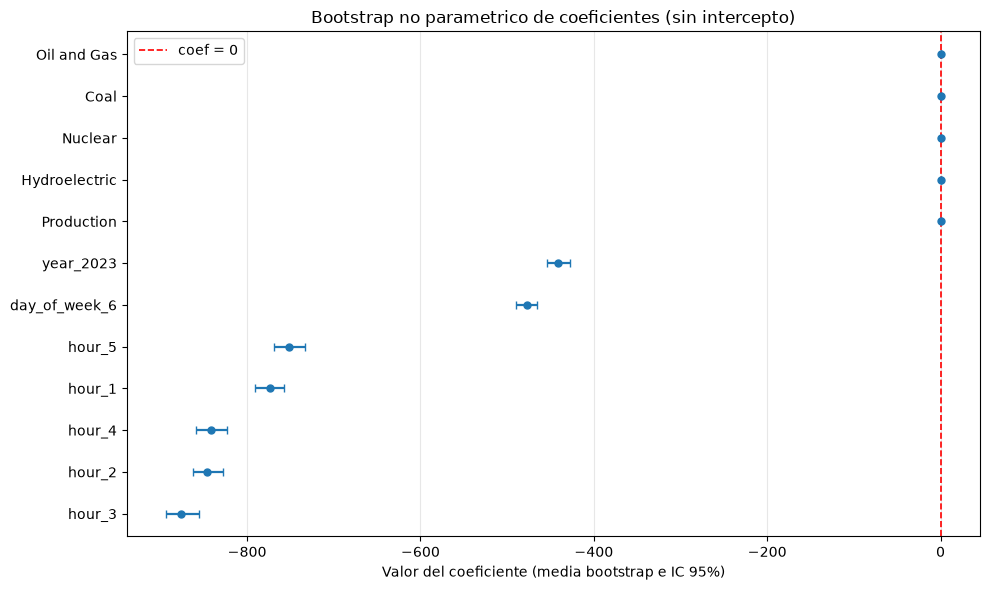

In [70]:
# Grafico de intervalos bootstrap (media e IC 95%)
if 'coef_boot_summary' not in globals():
    raise NameError("No existe 'coef_boot_summary'. Ejecuta antes la celda de bootstrap de coeficientes.")

plot_df = (
    coef_boot_summary
    .query("coeficiente != 'intercepto'")
    .copy()
    .sort_values('mean')
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, max(6, 0.45 * len(plot_df))))

y_pos = np.arange(len(plot_df))
err_left = plot_df['mean'] - plot_df['p2.5']
err_right = plot_df['p97.5'] - plot_df['mean']

ax.errorbar(
    plot_df['mean'],
    y_pos,
    xerr=[err_left, err_right],
    fmt='o',
    color='tab:blue',
    ecolor='tab:blue',
    elinewidth=1.6,
    capsize=3,
    markersize=5,
)

ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='coef = 0')
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['coeficiente'])
ax.set_xlabel('Valor del coeficiente (media bootstrap e IC 95%)')
ax.set_title('Bootstrap no parametrico de coeficientes (sin intercepto)')
ax.grid(axis='x', alpha=0.3)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

### Densidades bootstrap por coeficiente (graficos independientes)

Este bloque genera un panel con un grafico de densidad independiente para cada coeficiente estimado por bootstrap.

Convenciones visuales:
- Histograma normalizado (`density=True`) para aproximar la densidad empirica.
- Linea azul punteada: media bootstrap.
- Lineas negras punteadas: percentiles 2.5% y 97.5%.
- Linea roja: referencia en 0.

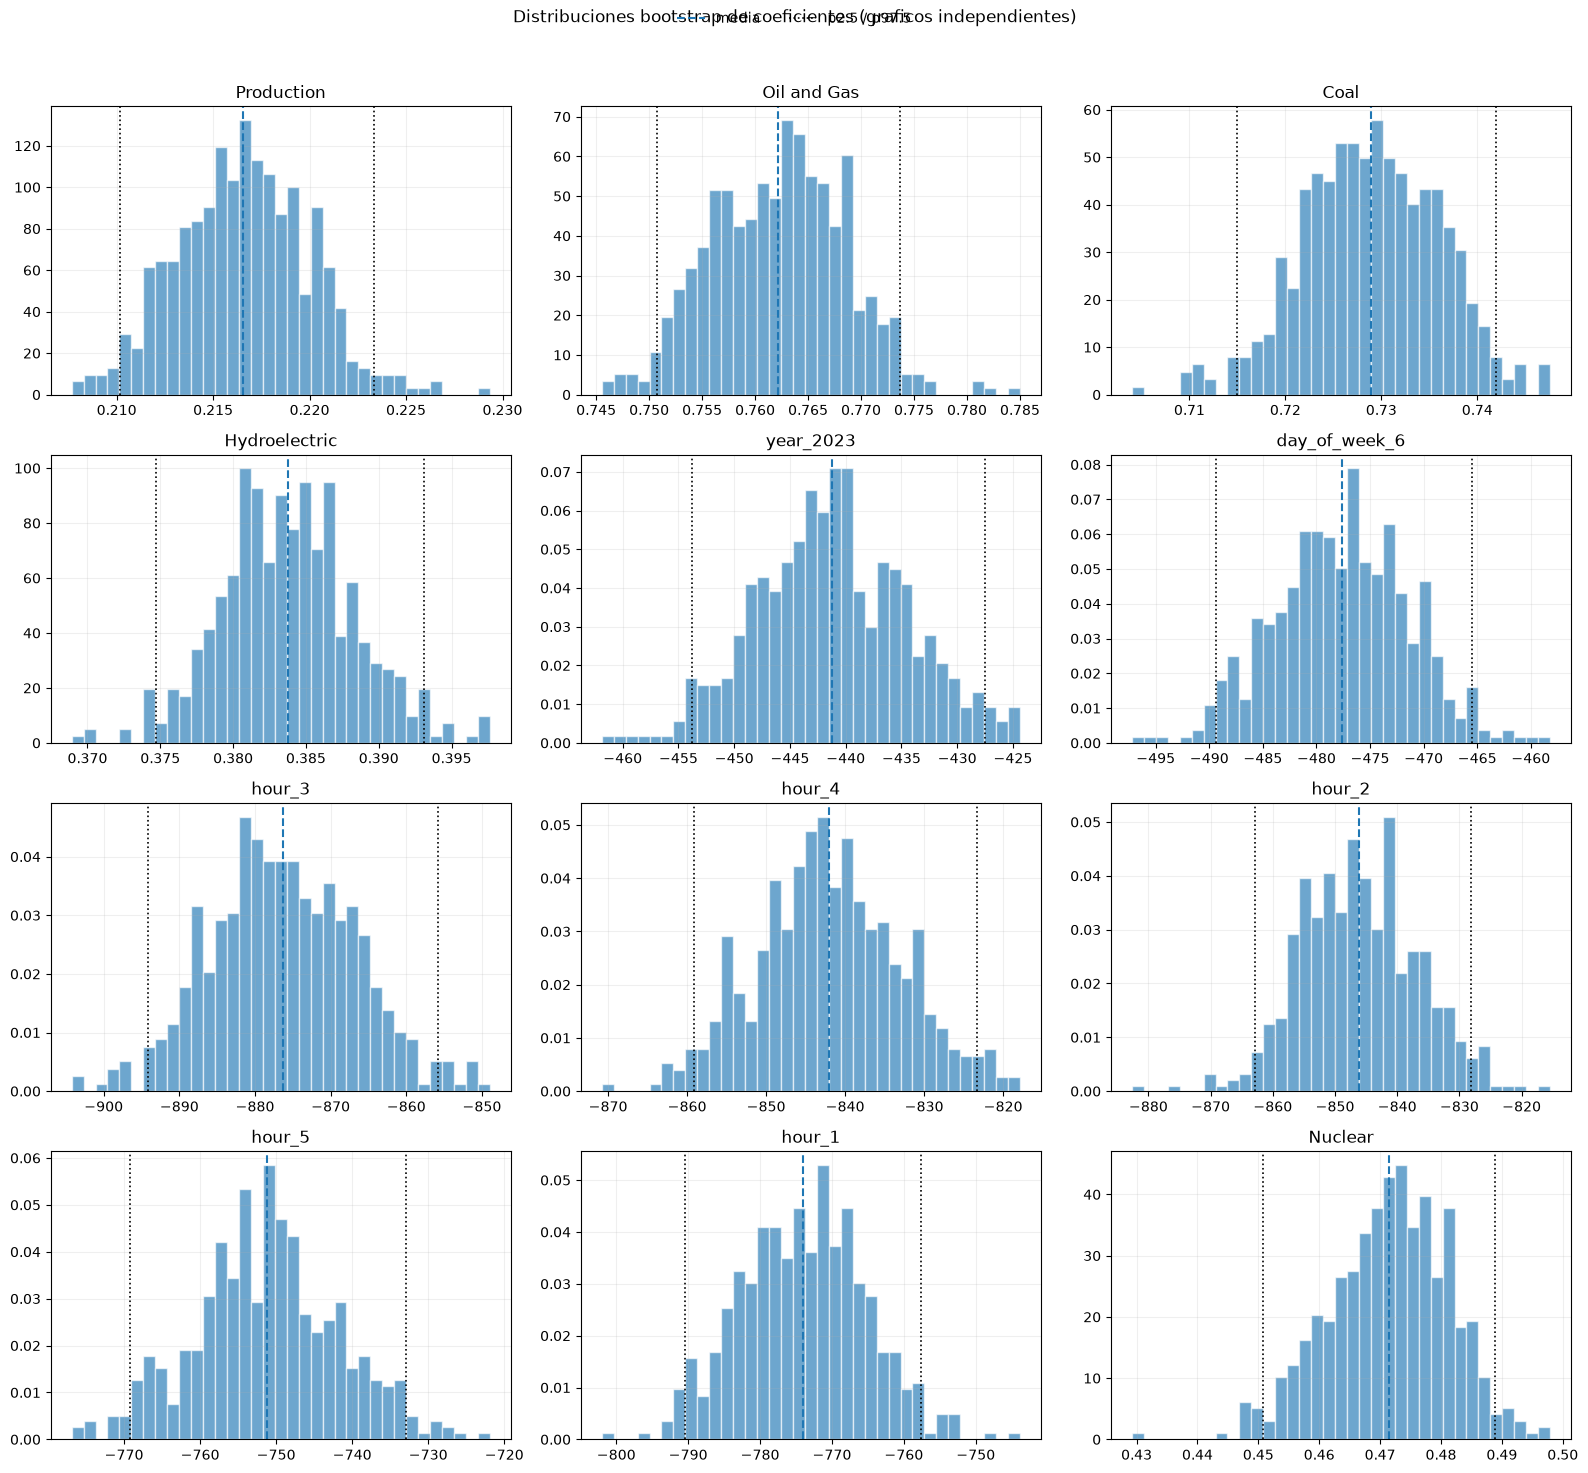

In [72]:
# Panel de densidades independientes por coeficiente bootstrap
if 'coef_boot_df' not in globals():
    raise NameError("No existe 'coef_boot_df'. Ejecuta antes la celda de bootstrap de coeficientes.")

include_intercept = False
coef_cols = list(coef_boot_df.columns)
if not include_intercept and 'intercepto' in coef_cols:
    coef_cols = [c for c in coef_cols if c != 'intercepto']

n_coef = len(coef_cols)
n_cols = 3
n_rows = int(np.ceil(n_coef / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.6 * n_rows))
axes = np.array(axes).reshape(-1)

for i, coef_name in enumerate(coef_cols):
    ax = axes[i]
    s = coef_boot_df[coef_name]

    ax.hist(s, bins=35, density=True, alpha=0.65, color='tab:blue', edgecolor='white')
    ax.axvline(s.mean(), color='tab:blue', linestyle='--', linewidth=1.5, label='media')
    ax.axvline(s.quantile(0.025), color='black', linestyle=':', linewidth=1.2, label='p2.5 / p97.5')
    ax.axvline(s.quantile(0.975), color='black', linestyle=':', linewidth=1.2)
    # ax.axvline(0, color='red', linestyle='-', linewidth=1.0, alpha=0.8, label='0')

    ax.set_title(coef_name)
    ax.grid(alpha=0.2)

# Ocultar ejes vacios del panel
for j in range(n_coef, len(axes)):
    axes[j].axis('off')

# Leyenda unica
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False)
fig.suptitle('Distribuciones bootstrap de coeficientes (graficos independientes)', y=1.02)

plt.tight_layout()
plt.show()